In [40]:
import json
import pandas as pd
import tweepy
import re
import matplotlib.pyplot as plt
import seaborn as sns

## Load data

In [7]:
#Function to format names
def format_name(name):
    # Split before an uppercase sequence that follows a lowercase letter
    parts = re.findall(r'[A-Z][a-z]+|(?:[A-Z]+(?=[A-Z]|$))', name)
    
    # Capitalize each part correctly
    formatted_parts = [part.capitalize() for part in parts]
    
    # Join the parts with a space
    return ' '.join(formatted_parts)

In [18]:
#### Load Tweets
with open('tweets_final_top.json') as f:
    data1 = json.load(f)

with open('tweets_final.json') as f:
    data2 = json.load(f)

# Convert lists of dictionaries into DataFrames
df1 = pd.DataFrame(data1)
df2 = pd.DataFrame(data2)

# Combine the two DataFrames
combined_df = pd.concat([df1, df2], ignore_index=True)

# Remove duplicates based on the specified columns
df = combined_df.drop_duplicates(subset=['created_at', 'username', 'Text', 'Competitor'])


### Load race results

with open('final_results.json') as f:
    results = json.load(f)

for entry in results:
        if 'Name' in entry:
            entry['Name'] = format_name(entry['Name'])

results = pd.DataFrame(results)
results.rename(columns={'Name': 'Competitor'}, inplace=True)

In [3]:
# Display the DataFrame's columns
df.describe()

,created_at,username,Text,Competitor
count,645,645,645,645
unique,564,431,565,22
top,Wed Aug 07 10:14:10 +0000 2024,FloTrack,[🏃‍♂️] Les athlètes qualifiés en finale du 5 0...,Oscar Chelimo
freq,7,9,7,40


In [11]:
competitor_counts = df.groupby('Competitor').size()

print(competitor_counts)

Competitor
Addisu Yihune               31
Biniam Mehary               19
Dawit Seare                 21
Dominic Lokinyomo Lobalu    18
Edwin Kurgat                27
George Mills                33
Graham Blanks               21
Grant Fisher                38
Hagos Gebrhiwet             18
Hugo Hay                    39
Isaac Kimeli                34
Jacob Krop                  29
Jakob Ingebrigtsen          36
John Heymans                32
Mike Foppen                 33
Narve Gilje Nordas          29
Oscar Chelimo               40
Ronald Kwemoi               27
Stewart Mcsweyn             18
Thierry Ndikumwenayo        35
Thomas Fafard               33
Yann Schrub                 34
dtype: int64


In [13]:
# Load hugging face token
with open('hf_token.json') as file:
    json_obj = json.load(file)
    key=json_obj["Key"]

George Mills and Hugo Hay collided. Mills, Woody Kincaid, Jonah Koech and Birhanu Balew all crahed and were moved into the final because of this disadvantage.

## BERT (Bidirectional Encoder Representations from Transformers) - Based Models

Transformers is a deep learning model that uses positional encoding and self-attention. With positional encoding the model assigns a unique number to each word, ensuring that sequencial information is also being considered. Self-attention refers to the model learning the weights of a word appearing in a sequence and thus being able to predict word which are likely to be used in a sentence.

BERT models are an open-source machine learning framework for natural language processing (NLP) pretrained on Wikipedia articles and is being used in Google search. The model was trained on masked language modelling (MLM), where a word in a sentence is hidden and the model has to predict the word and next sentence predcition (NSP) predicting wether two sentences belong together or not.

### Model: cardiffnlp/twitter-roberta-base-sentiment 

Specifically fine-tuned on Twitter data for sentiment analysis. It is a RoBERTa-based model that has been trained to classify sentiments into positive, negative, and neutral categories.

Label 0 corresponds to negative sentiment, label 1 to neutral sentiment and label 2 to positive sentiment.

#### Set-up model

In [92]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import pipeline

# Load the pre-trained model and tokenizer
model_name = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Create a pipeline for sentiment analysis
sentiment_pipeline = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

# Function to get sentiment for each tweet
def get_sentiment(text):
    result = sentiment_pipeline(text)
    return result[0]['label'], result[0]['score']

# Apply the sentiment analysis to the "Text" column
df.loc[:, 'Sentiment'], df.loc[:, 'Confidence'] = zip(*df['Text'].apply(get_sentiment))


c:\Users\leaka\anaconda3\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
c:\Users\leaka\anaconda3\lib\site-packages\pandas\core\indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


In [93]:
# Map sentiment labels to descriptive names
sentiment_labels = {'LABEL_0': 'Negative', 'LABEL_1': 'Neutral', 'LABEL_2': 'Positive'}
df['Sentiment_Label'] = df['Sentiment'].map(sentiment_labels)

# Group by 'Athlete' and 'Sentiment_Label' and count occurrences
sentiment_counts = df.groupby(['Competitor', 'Sentiment_Label']).size().unstack(fill_value=0)

# Rename columns for clarity
sentiment_counts.columns = ['Negative', 'Neutral', 'Positive']



# Calculate total tweets
sentiment_counts['Total_Tweets'] = sentiment_counts.sum(axis=1)

# Calculate ratio of positive tweets
sentiment_counts['Positive_Ratio'] = sentiment_counts['Positive'] / sentiment_counts['Total_Tweets']

sorted_sentiment_counts = sentiment_counts.sort_values(by='Positive_Ratio', ascending=False)

print(sorted_sentiment_counts[['Positive_Ratio']])

                          Positive_Ratio
Competitor                              
Dawit Seare                     0.571429
Grant Fisher                    0.473684
Graham Blanks                   0.380952
Jakob Ingebrigtsen              0.333333
Dominic Lokinyomo Lobalu        0.333333
Ronald Kwemoi                   0.296296
Edwin Kurgat                    0.259259
Addisu Yihune                   0.225806
Oscar Chelimo                   0.225000
Narve Gilje Nordas              0.206897
Jacob Krop                      0.206897
Biniam Mehary                   0.157895
Thomas Fafard                   0.151515
John Heymans                    0.125000
Mike Foppen                     0.121212
George Mills                    0.090909
Isaac Kimeli                    0.088235
Hagos Gebrhiwet                 0.055556
Stewart Mcsweyn                 0.055556
Yann Schrub                     0.029412
Thierry Ndikumwenayo            0.028571
Hugo Hay                        0.000000


<ipython-input-93-d67bfb7e73ab>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sentiment_Label'] = df['Sentiment'].map(sentiment_labels)


In [94]:
#Merge with actural results
df_all = pd.merge(results, sentiment_counts, on='Competitor', how='left')
df_all.set_index('Competitor', inplace=True)
df_all['Position'] = pd.to_numeric(df_all['Position'], errors='coerce')
df_all['Time_Seconds'] = pd.to_timedelta('00:' + df_all['Time']).dt.total_seconds()

#### Visualize the results

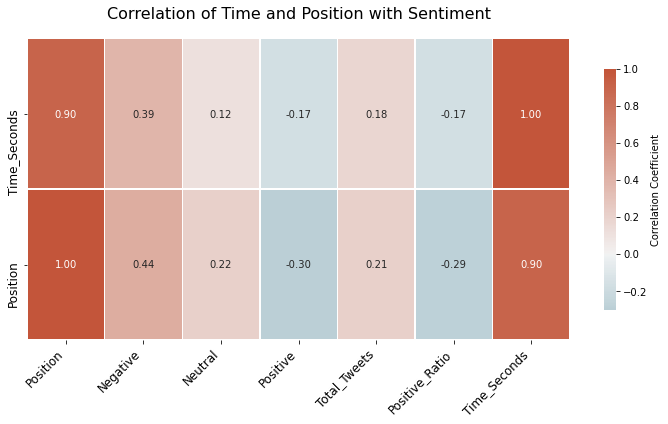

In [95]:
# Generate correlation matrix
corr_matrix = df_all.corr()

# Focus on correlations of 'Time' and 'Position' with all other columns
focused_corr = corr_matrix.loc[['Time_Seconds', 'Position']]


# Create the heatmap
plt.figure(figsize=(10, 6))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

# Draw the heatmap
sns.heatmap(
    focused_corr, 
    annot=True, 
    fmt=".2f", 
    cmap=cmap, 
    center=0, 
    linewidths=0.5, 
    linecolor='white',
    cbar_kws={'shrink': .8, 'label': 'Correlation Coefficient'}
)

# Set axis labels
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.title('Correlation of Time and Position with Sentiment', fontsize=16, pad=20)
plt.tight_layout()

# save
plt.savefig('Correltion Matrix Model 1', format="png")


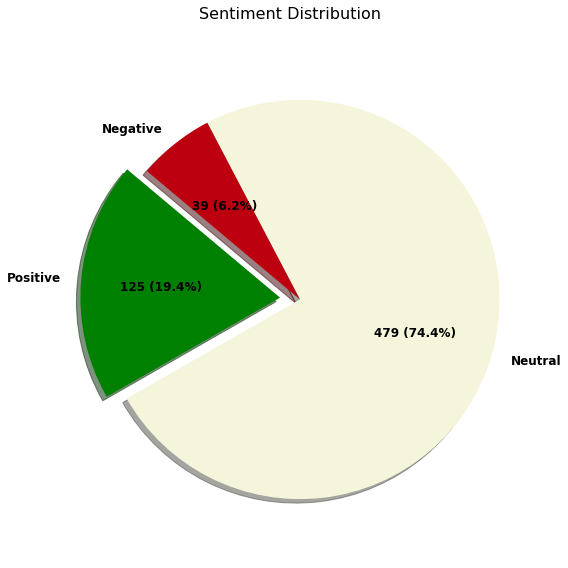

In [98]:
###Pie chart of sentiment distrubution###

positive = df_all['Positive'].sum()
negative = df_all['Negative'].sum()
neutral = df_all['Neutral'].sum()

# Sample sentiment data
sentiment_counts = {
    'Positive': positive,
    'Neutral': neutral,
    'Negative': negative
}

# Data preparation
labels = sentiment_counts.keys()
sizes = sentiment_counts.values()
colors = ['#008000','#F5F5DC','#BC000F']  # Colors for different sentiments
explode = (0.1, 0, 0)  # Explode the 1st slice (Positive)

# Function to format the labels
def func(pct, all_values):
    absolute = int(pct / 100. * sum(all_values))
    return f'{absolute} ({pct:.1f}%)'

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    sizes, 
    explode=explode, 
    labels=labels, 
    colors=colors, 
    autopct=lambda pct: func(pct, sizes),  
    shadow=True, 
    startangle=140, 
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

# Title and other customizations
plt.title('Sentiment Distribution', fontsize=16, pad=20)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Show the plot
plt.tight_layout()

# save
plt.savefig('Pie Chart Sentiment Model 1', format="png")

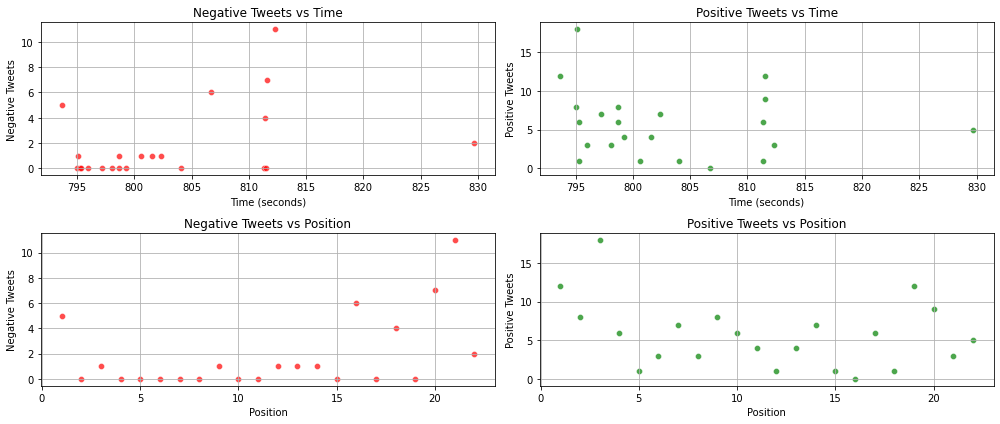

In [99]:

# Scatter plot for Negative Tweets vs Time
plt.figure(figsize=(14, 6))

plt.subplot(2, 2, 1)
sns.scatterplot(data=df_all, x='Time_Seconds', y='Negative', alpha=0.7, color='red')
plt.title('Negative Tweets vs Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Negative Tweets')
plt.grid(True)

# Scatter plot for Positive Tweets vs Time

plt.subplot(2, 2, 2)
sns.scatterplot(data=df_all, x='Time_Seconds', y='Positive', alpha=0.7, color='green')
plt.title('Positive Tweets vs Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Positive Tweets')
plt.grid(True)

# Scatter plot for Negative Tweets vs Position

plt.subplot(2, 2, 3)
sns.scatterplot(data=df_all, x='Position', y='Negative', alpha=0.7, color='red')
plt.title('Negative Tweets vs Position')
plt.xlabel('Position')
plt.ylabel('Negative Tweets')
plt.grid(True)

# Scatter plot for Positive Tweets vs Position

plt.subplot(2, 2, 4)
sns.scatterplot(data=df_all, x='Position', y='Positive', alpha=0.7, color='green')
plt.title('Positive Tweets vs Position')
plt.xlabel('Position')
plt.ylabel('Positive Tweets')
plt.grid(True)

plt.tight_layout()
# save
plt.savefig('Scatter Plot Model 1', format="png")


### Model: nlptown/bert-base-multilingual-uncased-sentiment

A BERT-based model fine-tuned for sentiment analysis across multiple languages. It classifies sentiments into five categories: very negative, negative, neutral, positive, and very positive.

#### Set-up model

In [58]:
# Load the pre-trained model and tokenizer
model_name = "nlptown/bert-base-multilingual-uncased-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Create a pipeline for sentiment analysis
sentiment_pipeline = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

# Function to get sentiment for each tweet
def get_sentiment(text):
    result = sentiment_pipeline(text)
    return result[0]['label'], result[0]['score']

# Apply the sentiment analysis to the "Text" column
df.loc[:, 'Sentiment'], df.loc[:, 'Confidence'] = zip(*df['Text'].apply(get_sentiment))

c:\Users\leaka\anaconda3\lib\site-packages\pandas\core\indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


In [71]:

# Group by 'Athlete' and 'Sentiment_Label' and count occurrences
sentiment_counts = df.groupby(['Competitor', 'Sentiment']).size().unstack(fill_value=0)
# Rename columns for clarity
sentiment_counts.columns = ['Very negative', 'Negative', 'Neutral', 'Positive', 'Very positive']

# Calculate total tweets
sentiment_counts['Total_Tweets'] = sentiment_counts.sum(axis=1)

# Calculate ratio of positive tweets
sentiment_counts['Positive_Ratio'] = (sentiment_counts['Positive']+sentiment_counts['Very positive'] )/ sentiment_counts['Total_Tweets']

sorted_sentiment_counts = sentiment_counts.sort_values(by='Positive_Ratio', ascending=False)

print(sorted_sentiment_counts[['Positive_Ratio']])

                          Positive_Ratio
Competitor                              
Dawit Seare                     0.952381
Jacob Krop                      0.862069
Edwin Kurgat                    0.851852
Grant Fisher                    0.789474
Ronald Kwemoi                   0.777778
Graham Blanks                   0.714286
Biniam Mehary                   0.684211
Hagos Gebrhiwet                 0.666667
Addisu Yihune                   0.612903
Oscar Chelimo                   0.600000
Narve Gilje Nordas              0.586207
Mike Foppen                     0.575758
Jakob Ingebrigtsen              0.555556
Stewart Mcsweyn                 0.500000
Thomas Fafard                   0.484848
John Heymans                    0.468750
George Mills                    0.454545
Dominic Lokinyomo Lobalu        0.444444
Isaac Kimeli                    0.411765
Yann Schrub                     0.411765
Thierry Ndikumwenayo            0.371429
Hugo Hay                        0.179487


In [72]:
#Merge with actural results
df_all = pd.merge(results, sentiment_counts, on='Competitor', how='left')
df_all.set_index('Competitor', inplace=True)
df_all['Position'] = pd.to_numeric(df_all['Position'], errors='coerce')
df_all['Time_Seconds'] = pd.to_timedelta('00:' + df_all['Time']).dt.total_seconds()

#### Visualize results

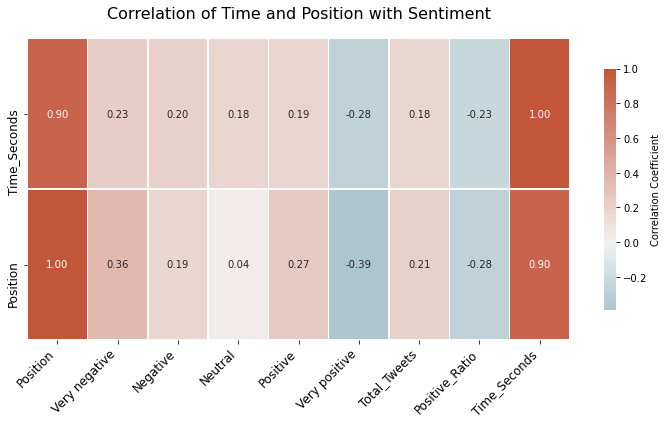

In [80]:
# Generate correlation matrix
corr_matrix = df_all.corr()

# Focus on correlations of 'Time' and 'Position' with all other columns
focused_corr = corr_matrix.loc[['Time_Seconds', 'Position']]


# Create the heatmap
plt.figure(figsize=(10, 6))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

# Draw the heatmap
sns.heatmap(
    focused_corr, 
    annot=True, 
    fmt=".2f", 
    cmap=cmap, 
    center=0, 
    linewidths=0.5, 
    linecolor='white',
    cbar_kws={'shrink': .8, 'label': 'Correlation Coefficient'}
)

# Set axis labels
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.title('Correlation of Time and Position with Sentiment', fontsize=16, pad=20)
plt.tight_layout()

# save
plt.savefig('Correlation Matrix Model 2', format="png")


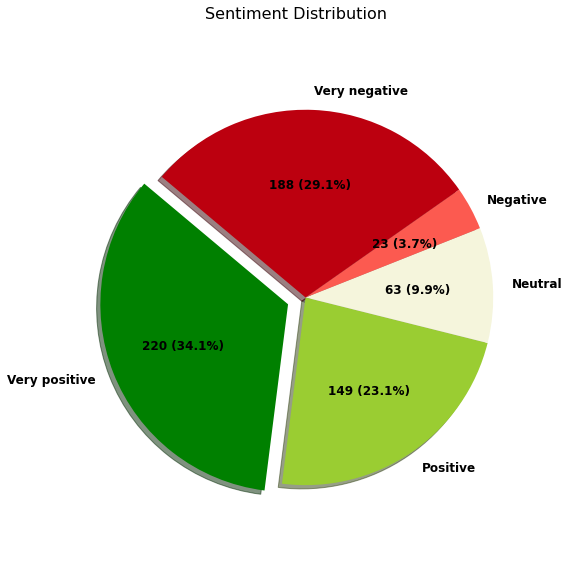

In [79]:
###Pie chart of sentiment distrubution###

vpositive = df_all['Very positive'].sum()
positive = df_all['Positive'].sum()
negative = df_all['Negative'].sum()
vnegative = df_all['Very negative'].sum()
neutral = df_all['Neutral'].sum()

# Sample sentiment data
sentiment_counts = {
    'Very positive': vpositive,
    'Positive': positive,
    'Neutral': neutral,
    'Negative': negative,
    'Very negative': vnegative
}

# Data preparation
labels = sentiment_counts.keys()
sizes = sentiment_counts.values()
colors = ['#008000','#9ACD32','#F5F5DC','#FC5A50', '#BC000F']  # Colors for different sentiments
explode = (0.1, 0.1, 0,0,0)  # Explode the 1st  and 2nd slice (Very positive, positive)

# Function to format the labels
def func(pct, all_values):
    absolute = int(pct / 100. * sum(all_values))
    return f'{absolute} ({pct:.1f}%)'

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    sizes, 
    explode=explode, 
    labels=labels, 
    colors=colors, 
    autopct=lambda pct: func(pct, sizes),  
    shadow=True, 
    startangle=140, 
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

# Title and other customizations
plt.title('Sentiment Distribution', fontsize=16, pad=20)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Show the plot
plt.tight_layout()

# save
plt.savefig('Pie Chart Sentiment Model 2', format="png")

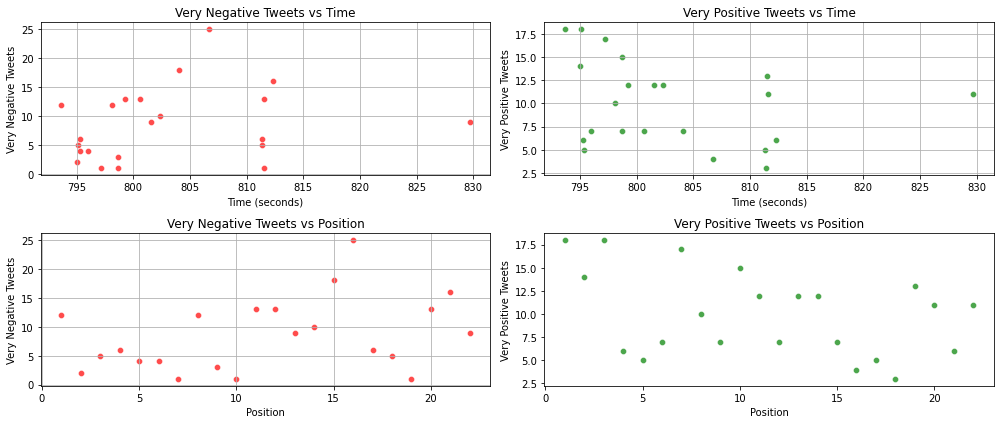

In [91]:

# Scatter plot for Very Negative Tweets vs Time
plt.figure(figsize=(14, 6))

plt.subplot(2, 2, 1)
sns.scatterplot(data=df_all, x='Time_Seconds', y='Very negative', alpha=0.7, color='red')
plt.title('Very Negative Tweets vs Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Very Negative Tweets')
plt.grid(True)

# Scatter plot for Very Positive Tweets vs Time

plt.subplot(2, 2, 2)
sns.scatterplot(data=df_all, x='Time_Seconds', y='Very positive', alpha=0.7, color='green')
plt.title('Very Positive Tweets vs Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Very Positive Tweets')
plt.grid(True)

# Scatter plot for Very Negative Tweets vs Position

plt.subplot(2, 2, 3)
sns.scatterplot(data=df_all, x='Position', y='Very negative', alpha=0.7, color='red')
plt.title('Very Negative Tweets vs Position')
plt.xlabel('Position')
plt.ylabel('Very Negative Tweets')
plt.grid(True)

# Scatter plot for Very Positive Tweets vs Position

plt.subplot(2, 2, 4)
sns.scatterplot(data=df_all, x='Position', y='Very positive', alpha=0.7, color='green')
plt.title('Very Positive Tweets vs Position')
plt.xlabel('Position')
plt.ylabel('Very Positive Tweets')
plt.grid(True)

plt.tight_layout()
# save
plt.savefig('Scatter Plot Model 2', format="png")
